# IMDb KNN Classification

This beginner-friendly project uses **K-Nearest Neighbors (KNN)** to classify IMDb movies as:

- `1` = High Rated (`IMDB_Rating >= 8.0`)
- `0` = Not High Rated (`IMDB_Rating < 8.0`)

The project follows the KNN concepts from the course notes: **K**, distance, `weights`, neighbor-search algorithms, scaling, classification metrics, and confusion matrix.

> Important: `IMDB_Rating` is used only to create the target. It is **not** included in the model features, because that would leak the answer to the model.

## 1. Import Libraries

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)


## 2. Load Dataset

In [2]:
# Works whether Jupyter starts inside notebooks/ or at the project root.
data_path = Path("../data/imdb_top_1000.csv")

if not data_path.exists():
    data_path = Path("data/imdb_top_1000.csv")

df = pd.read_csv(data_path)

df.head()


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (1000, 16)

Columns:
['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [5]:
df.isnull().sum()


Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

## 3. Data Cleaning

The numeric columns need a little cleaning:

- `Runtime`: remove `" min"`
- `Gross`: remove commas and convert to a number
- `Released_Year`: convert to numeric
- Missing `Meta_score` and `Gross`: fill with the median
- Missing `Certificate`: replace with `"Unknown"`

In [6]:
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")

df["Runtime"] = (
    df["Runtime"]
    .str.replace(" min", "", regex=False)
)
df["Runtime"] = pd.to_numeric(df["Runtime"], errors="coerce")

df["Gross"] = (
    df["Gross"]
    .str.replace(",", "", regex=False)
)
df["Gross"] = pd.to_numeric(df["Gross"], errors="coerce")

df["Meta_score"] = df["Meta_score"].fillna(df["Meta_score"].median())
df["Gross"] = df["Gross"].fillna(df["Gross"].median())
df["Certificate"] = df["Certificate"].fillna("Unknown")

# Only one Released_Year value is not numeric in this dataset.
df = df.dropna(subset=["Released_Year"]).reset_index(drop=True)


In [7]:
df[
    ["Released_Year", "Runtime", "Meta_score", "Gross", "Certificate"]
].isnull().sum()


Released_Year    0
Runtime          0
Meta_score       0
Gross            0
Certificate      0
dtype: int64

## 4. Create the Classification Target

In [8]:
df["High_Rated"] = (df["IMDB_Rating"] >= 8.0).astype(int)

print(df["High_Rated"].value_counts())
print("\nPercentage:")
print((df["High_Rated"].value_counts(normalize=True) * 100).round(2))


High_Rated
0    536
1    463
Name: count, dtype: int64

Percentage:
High_Rated
0    53.65
1    46.35
Name: proportion, dtype: float64


## 5. Feature Engineering

We use the features we selected for this project:

### Numeric
- Released Year
- Runtime
- Meta Score
- Number of Votes
- Gross Revenue

### Categorical
- Genre
- Certificate

`No_of_Votes` and `Gross` are strongly right-skewed, so `log1p` is used before scaling.  
This prevents very large values from dominating KNN distance calculations.

In [9]:
df["No_of_Votes_log"] = np.log1p(df["No_of_Votes"])
df["Gross_log"] = np.log1p(df["Gross"])

numeric_features = [
    "Released_Year",
    "Runtime",
    "Meta_score",
    "No_of_Votes_log",
    "Gross_log",
]

X_numeric = df[numeric_features].copy()

genre_encoded = df["Genre"].str.get_dummies(sep=", ").astype(int)

certificate_encoded = pd.get_dummies(
    df["Certificate"],
    prefix="Certificate",
    dtype=int,
)

X_categorical = pd.concat(
    [genre_encoded, certificate_encoded],
    axis=1,
)

y = df["High_Rated"].copy()

print("Numeric features:", X_numeric.shape[1])
print("Categorical features:", X_categorical.shape[1])
print("Total features:", X_numeric.shape[1] + X_categorical.shape[1])


Numeric features: 5
Categorical features: 38
Total features: 43


## 6. Train / Validation / Test Split

We keep a separate **validation set** for choosing KNN settings.

- Train: 60%
- Validation: 20%
- Test: 20%

The test set is not used when choosing `K`, `weights`, or distance metric.

In [10]:
all_indices = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.40,
    random_state=42,
    stratify=y,
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=y.iloc[temp_idx],
)

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))


Train: 599
Validation: 200
Test: 200


## 7. Scale Only Numeric Features

KNN is distance-based, so scaling is important.

We fit `StandardScaler` **only on the training numeric data**.  
The one-hot encoded Genre and Certificate columns stay as `0/1`.

In [11]:
scaler = StandardScaler()

X_train_num = pd.DataFrame(
    scaler.fit_transform(X_numeric.iloc[train_idx]),
    columns=numeric_features,
)

X_val_num = pd.DataFrame(
    scaler.transform(X_numeric.iloc[val_idx]),
    columns=numeric_features,
)

X_test_num = pd.DataFrame(
    scaler.transform(X_numeric.iloc[test_idx]),
    columns=numeric_features,
)

X_train_cat = X_categorical.iloc[train_idx].reset_index(drop=True)
X_val_cat = X_categorical.iloc[val_idx].reset_index(drop=True)
X_test_cat = X_categorical.iloc[test_idx].reset_index(drop=True)

X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_val = pd.concat([X_val_num, X_val_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

y_train = y.iloc[train_idx].reset_index(drop=True)
y_val = y.iloc[val_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


X_train: (599, 43)
X_val: (200, 43)
X_test: (200, 43)


## 8. Baseline KNN Model

In [12]:
baseline_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    algorithm="auto",
    p=2,  # Euclidean distance
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_val)

print("Baseline Validation Metrics")
print("Accuracy :", round(accuracy_score(y_val, baseline_pred), 3))
print("Precision:", round(precision_score(y_val, baseline_pred), 3))
print("Recall   :", round(recall_score(y_val, baseline_pred), 3))
print("F1 Score :", round(f1_score(y_val, baseline_pred), 3))


Baseline Validation Metrics
Accuracy : 0.68
Precision: 0.675
Recall   : 0.602
F1 Score : 0.636


## 9. Tune K, Weights, and Distance

Instead of choosing K only by Accuracy, this project selects the settings using **F1 score for class 1 (High Rated)**.

We compare:

- `K = 1, 3, 5, ..., 31`
- `weights = uniform / distance`
- `p = 1` → Manhattan distance
- `p = 2` → Euclidean distance

In [13]:
results = []

for k in range(1, 32, 2):
    for weight in ["uniform", "distance"]:
        for p_value in [1, 2]:

            model = KNeighborsClassifier(
                n_neighbors=k,
                weights=weight,
                algorithm="auto",
                p=p_value,
            )

            model.fit(X_train, y_train)
            pred = model.predict(X_val)

            results.append(
                {
                    "k": k,
                    "weights": weight,
                    "p": p_value,
                    "accuracy": accuracy_score(y_val, pred),
                    "precision": precision_score(y_val, pred, zero_division=0),
                    "recall": recall_score(y_val, pred, zero_division=0),
                    "f1": f1_score(y_val, pred, zero_division=0),
                }
            )

results_df = pd.DataFrame(results).sort_values(
    by=["f1", "accuracy"],
    ascending=False,
).reset_index(drop=True)

results_df.head(10)


,k,weights,p,accuracy,precision,recall,f1
0,25,distance,1,0.735,0.750000,0.645161,0.693642
1,17,uniform,2,0.730,0.760000,0.612903,0.678571
2,9,distance,2,0.725,0.743590,0.623656,0.678363
3,15,distance,2,0.725,0.750000,0.612903,0.674556
4,17,distance,2,0.725,0.750000,0.612903,0.674556
5,3,distance,1,0.710,0.705882,0.645161,0.674157
6,29,distance,1,0.725,0.756757,0.602151,0.670659
7,9,uniform,2,0.720,0.740260,0.612903,0.670588
8,13,distance,2,0.720,0.740260,0.612903,0.670588
9,15,uniform,2,0.720,0.740260,0.612903,0.670588


### Best F1 for each K

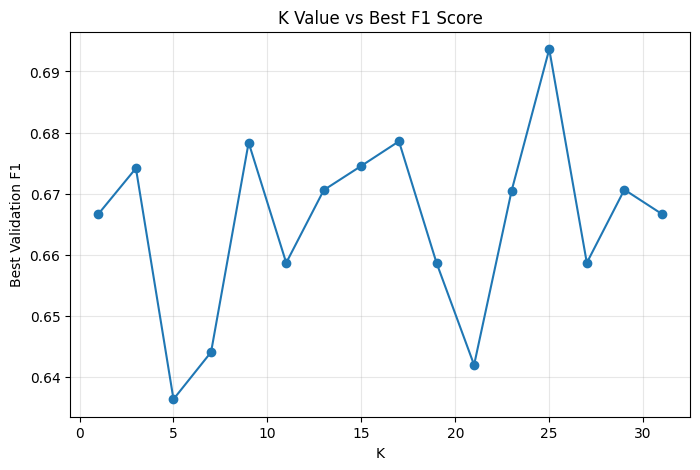

In [14]:
best_f1_by_k = results_df.groupby("k")["f1"].max().sort_index()

plt.figure(figsize=(8, 5))
plt.plot(
    best_f1_by_k.index,
    best_f1_by_k.values,
    marker="o",
)
plt.xlabel("K")
plt.ylabel("Best Validation F1")
plt.title("K Value vs Best F1 Score")
plt.grid(alpha=0.3)
plt.show()


### Best Hyperparameters

In [15]:
best_row = results_df.iloc[0]

best_k = int(best_row["k"])
best_weight = best_row["weights"]
best_p = int(best_row["p"])

print("Best K:", best_k)
print("Best weights:", best_weight)
print(
    "Best distance:",
    "Manhattan" if best_p == 1 else "Euclidean",
)
print("Validation F1:", round(best_row["f1"], 3))
print("Validation Accuracy:", round(best_row["accuracy"], 3))


Best K: 25
Best weights: distance
Best distance: Manhattan
Validation F1: 0.694
Validation Accuracy: 0.735


## 10. Compare Neighbor Search Algorithms

In [16]:
algorithm_results = []

for algorithm in ["auto", "brute", "kd_tree", "ball_tree"]:
    start = time.perf_counter()

    model = KNeighborsClassifier(
        n_neighbors=best_k,
        weights=best_weight,
        algorithm=algorithm,
        p=best_p,
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    elapsed = time.perf_counter() - start

    algorithm_results.append(
        {
            "algorithm": algorithm,
            "f1": f1_score(y_val, pred, zero_division=0),
            "accuracy": accuracy_score(y_val, pred),
            "time_seconds": elapsed,
        }
    )

algorithm_results_df = pd.DataFrame(algorithm_results)
algorithm_results_df


,algorithm,f1,accuracy,time_seconds
0,auto,0.693642,0.735,0.019420
1,brute,0.693642,0.735,0.015720
2,kd_tree,0.693642,0.735,0.017420
3,ball_tree,0.693642,0.735,0.013749


The search algorithm mainly changes **how neighbors are found** and therefore often changes speed more than predictive quality.

## 11. Tuned KNN on the Validation Set

In [17]:
tuned_model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights=best_weight,
    algorithm="auto",
    p=best_p,
)

tuned_model.fit(X_train, y_train)
tuned_val_pred = tuned_model.predict(X_val)

print(classification_report(y_val, tuned_val_pred))


              precision    recall  f1-score   support

           0       0.72      0.81      0.77       107
           1       0.75      0.65      0.69        93

    accuracy                           0.73       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.74      0.73      0.73       200



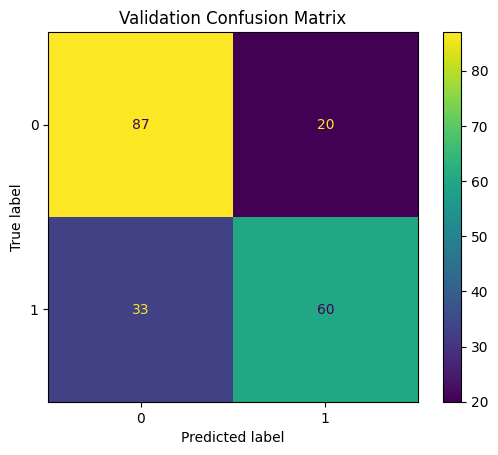

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    tuned_val_pred,
)
plt.title("Validation Confusion Matrix")
plt.show()


## 12. Bonus: Tune the Decision Threshold for F1

KNN normally uses a 0.50 probability threshold for class 1.  
Because our main goal is a better balance between **Precision** and **Recall**, we can test a few thresholds on the validation set and select the one with the best F1.

This section is optional, but it is useful for understanding why F1 can improve even when Accuracy does not.

In [19]:
val_prob = tuned_model.predict_proba(X_val)[:, 1]

threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.02):
    threshold_pred = (val_prob >= threshold).astype(int)

    threshold_results.append(
        {
            "threshold": round(float(threshold), 2),
            "precision": precision_score(
                y_val,
                threshold_pred,
                zero_division=0,
            ),
            "recall": recall_score(
                y_val,
                threshold_pred,
                zero_division=0,
            ),
            "f1": f1_score(
                y_val,
                threshold_pred,
                zero_division=0,
            ),
        }
    )

threshold_df = pd.DataFrame(threshold_results).sort_values(
    "f1",
    ascending=False,
).reset_index(drop=True)

threshold_df.head(10)


,threshold,precision,recall,f1
0,0.36,0.618321,0.870968,0.723214
1,0.44,0.683168,0.741935,0.711340
2,0.42,0.666667,0.752688,0.707071
3,0.34,0.591241,0.870968,0.704348
4,0.40,0.629310,0.784946,0.698565
5,0.38,0.608000,0.817204,0.697248
6,0.48,0.715909,0.677419,0.696133
7,0.46,0.691489,0.698925,0.695187
8,0.50,0.750000,0.645161,0.693642
9,0.32,0.539474,0.881720,0.669388


In [20]:
best_threshold = float(threshold_df.iloc[0]["threshold"])

print("Best validation threshold:", best_threshold)
print("Best validation F1:", round(threshold_df.iloc[0]["f1"], 3))


Best validation threshold: 0.36
Best validation F1: 0.723


## 13. Final Model and Test Evaluation

After choosing the KNN settings and threshold using the validation set, we combine the Train and Validation samples and evaluate **once** on the untouched Test set.

In [21]:
X_train_final = pd.concat(
    [X_train, X_val],
    axis=0,
    ignore_index=True,
)

y_train_final = pd.concat(
    [y_train, y_val],
    axis=0,
    ignore_index=True,
)

final_model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights=best_weight,
    algorithm="auto",
    p=best_p,
)

final_model.fit(X_train_final, y_train_final)


,n_neighbors,25
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Default KNN Prediction (0.50 threshold)

In [22]:
test_pred_default = final_model.predict(X_test)

print("Default-threshold Test Report")
print(classification_report(y_test, test_pred_default))

print("F1:", round(f1_score(y_test, test_pred_default), 3))


Default-threshold Test Report
              precision    recall  f1-score   support

           0       0.67      0.76      0.71       108
           1       0.67      0.57      0.61        92

    accuracy                           0.67       200
   macro avg       0.67      0.66      0.66       200
weighted avg       0.67      0.67      0.67       200

F1: 0.612


### F1-Tuned Threshold Prediction

In [23]:
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred_tuned = (test_prob >= best_threshold).astype(int)

print("Tuned-threshold Test Report")
print(classification_report(y_test, test_pred_tuned))

print("Accuracy :", round(accuracy_score(y_test, test_pred_tuned), 3))
print("Precision:", round(precision_score(y_test, test_pred_tuned), 3))
print("Recall   :", round(recall_score(y_test, test_pred_tuned), 3))
print("F1 Score :", round(f1_score(y_test, test_pred_tuned), 3))


Tuned-threshold Test Report
              precision    recall  f1-score   support

           0       0.77      0.49      0.60       108
           1       0.58      0.83      0.68        92

    accuracy                           0.65       200
   macro avg       0.67      0.66      0.64       200
weighted avg       0.68      0.65      0.64       200

Accuracy : 0.645
Precision: 0.58
Recall   : 0.826
F1 Score : 0.682


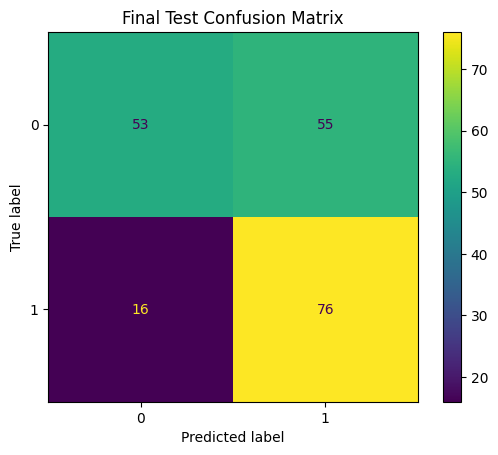

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred_tuned,
)
plt.title("Final Test Confusion Matrix")
plt.show()
#

## 14. Conclusion

This project applies KNN classification to IMDb movie data and practices:

- Data cleaning
- Feature selection and one-hot encoding
- Numeric feature scaling
- K-Nearest Neighbors classification
- Choosing K
- `uniform` vs `distance` weights
- Manhattan vs Euclidean distance
- `auto`, `brute`, `kd_tree`, and `ball_tree`
- Accuracy, Precision, Recall, and F1
- Confusion Matrix and Classification Report
- Optional decision-threshold tuning for F1

### Why this version is stronger

The original baseline scaled every feature, including one-hot categorical columns, and selected K mainly using Accuracy.  
This version:

1. Scales only numeric features.
2. Log-transforms highly skewed Votes and Gross values.
3. Uses a separate Validation set for model selection.
4. Chooses KNN settings based on F1 for the High-Rated class.
5. Keeps the Test set untouched until the final evaluation.